# NOTEBOOK TO GENERATE NYUD DATASET

In [4]:
import glob
import cv2

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
import os
from pymatreader import read_mat


%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 274 ms (started: 2024-11-30 23:21:53 -05:00)


### Loading data from .mat file

In [8]:
filename = "../data/nyu.mat"

data = None
# Open the .mat file
with h5py.File(filename , "r") as mat_file:
    data = {key: np.array(mat_file[key]) for key in mat_file.keys()}
    
    # Inspect the keys
    print("Keys in the file:", list(mat_file.keys()))

    # Access a dataset
    images = mat_file['images']  # Replace 'images' with the actual key in your file
    depths = mat_file['depths']  # Replace with actual key

    # Convert datasets to NumPy arrays
    images = images[()]  # If images is a dataset, this retrieves it as a NumPy array
    depths = depths[()]

Keys in the file: ['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']
time: 1min 15s (started: 2024-11-30 23:23:34 -05:00)


In [3]:
print(data.keys())

dict_keys(['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes'])
time: 527 µs (started: 2024-11-30 20:10:38 -05:00)


In [24]:
import pickle

sub_mat = {"images": data['images'], "instances": data['instances'], "labels": data['labels']}

with open('../resources/sub_mat.pkl', 'wb') as f:
    pickle.dump(sub_mat, f, protocol=pickle.HIGHEST_PROTOCOL)

time: 1.16 s (started: 2024-11-30 23:46:40 -05:00)


In [25]:
with open('../resources/sub_mat.pkl', 'rb') as f:
    sub_mat_loaded = pickle.load(f)

time: 1.16 s (started: 2024-11-30 23:47:20 -05:00)


In [9]:
print(f"Total number of images: {images.shape}")
print(f"Total number of labels: {depths.shape}")

Total number of images: (1449, 3, 640, 480)
Total number of labels: (1449, 640, 480)
time: 257 µs (started: 2024-11-26 23:42:51 -05:00)


### Visualize a depth map

In [12]:
print(depths[0].shape)

(640, 480)
time: 331 µs (started: 2024-11-26 23:43:20 -05:00)


In [13]:
print(np.rot90(depths[0], k=-1).shape)

(480, 640)
time: 399 µs (started: 2024-11-26 23:43:22 -05:00)


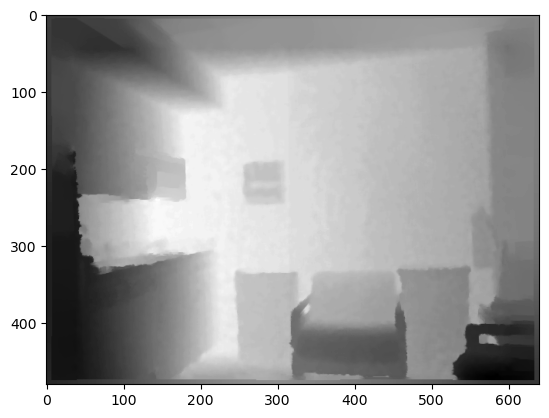

time: 114 ms (started: 2024-11-26 23:43:33 -05:00)


In [15]:
image = np.rot90(depths[0], k=-1)

plt.imshow(image, cmap="gray")

In [16]:
depth_map_tensor = torch.Tensor(depths)
print(depth_map_tensor.shape)

torch.Size([1449, 640, 480])
time: 2.48 ms (started: 2024-11-26 23:43:44 -05:00)


### Save depth values as tensors, just for a reference

In [9]:
torch.save(depth_map_tensor, "./depth_map.pth")

### Store depth maps as 16-bit PNG format images

In [17]:
print(type(depths))

<class 'numpy.ndarray'>
time: 323 µs (started: 2024-11-26 23:43:56 -05:00)


In [63]:
for idx in tqdm(range(depths.shape[0])): 
    depth_map = np.fliplr( np.rot90(depths[idx], k=-1))
    # depth_map = depths[idx]
    normalized_depth_map = np.uint16((depth_map - np.min(depth_map))/(np.max(depth_map) - np.min(depth_map)) * 65535)
    depth_image = Image.fromarray(normalized_depth_map)
    depth_image.save(f"../../NYUD/depth/{idx}.png")

print("All depth maps saved as png images!")

100%|██████████| 1449/1449 [01:28<00:00, 16.31it/s]

All depth maps saved as png images!
time: 1min 28s (started: 2024-11-27 00:49:01 -05:00)


### Raw Depth Maps

In [26]:
filename = "../data/nyu.mat"

# Open the .mat file
with h5py.File(filename , "r") as mat_file:
    # Inspect the keys
    print("Keys in the file:", list(mat_file.keys()))

    # Access a dataset
    images = mat_file['images']  # Replace 'images' with the actual key in your file
    raw_depths = mat_file['rawDepths']  # Replace with actual key

    # Convert datasets to NumPy arrays
    images = images[()]  # If images is a dataset, this retrieves it as a NumPy array
    raw_depths = raw_depths[()]

Keys in the file: ['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']
time: 23.9 s (started: 2024-11-26 23:58:53 -05:00)


In [27]:
print(f"Total number of images: {images.shape}")
print(f"Total number of rawDepths: {raw_depths.shape}")

Total number of images: (1449, 3, 640, 480)
Total number of rawDepths: (1449, 640, 480)
time: 312 µs (started: 2024-11-26 23:59:20 -05:00)


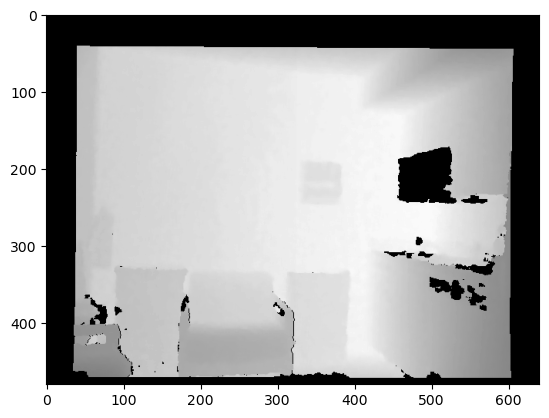

time: 123 ms (started: 2024-11-26 23:59:59 -05:00)


In [29]:
plt.imshow(np.fliplr(np.rot90(raw_depths[0], k=-1)), cmap="gray")

### Save raw depth maps as 16 bit PNG images

In [64]:
for idx in tqdm(range(raw_depths.shape[0])): 
    raw_depth_map = np.fliplr(np.rot90(raw_depths[idx], k=-1))
    # depth_map = depths[idx]
    normalized_raw_depth_map = np.uint16((raw_depth_map - np.min(raw_depth_map))/(np.max(raw_depth_map) - np.min(raw_depth_map)) * 65535)
    raw_depth_image = Image.fromarray(normalized_raw_depth_map)
    raw_depth_image.save(f"../../NYUD/raw_depth/{idx}.png")

print("All raw depth maps saved as png images!")

100%|██████████| 1449/1449 [00:52<00:00, 27.71it/s]

All raw depth maps saved as png images!
time: 52.3 s (started: 2024-11-27 00:50:50 -05:00)


### Save RGB images

In [33]:
print(images.shape)

(1449, 3, 640, 480)
time: 782 µs (started: 2024-11-27 00:08:19 -05:00)


In [34]:
print(images[0].shape)

(3, 640, 480)
time: 216 µs (started: 2024-11-27 00:09:56 -05:00)


In [65]:
for idx in tqdm(range(images.shape[0])): 
    image_array = np.fliplr(np.rot90(np.transpose(images[idx], (1, 2, 0)), k=-1))
    # depth_map = depths[idx]
    normalized_image_array = np.uint8((image_array - np.min(image_array))/(np.max(image_array) - np.min(image_array)) * 65535)
    image = Image.fromarray(normalized_image_array)
    image.save(f"../../NYUD/{idx}.png")

print("All raw depth maps saved as png images!")

100%|██████████| 1449/1449 [02:32<00:00,  9.48it/s]

All raw depth maps saved as png images!
time: 2min 32s (started: 2024-11-27 00:51:55 -05:00)


### Data Summary

In [3]:
images_dir = "../../NYUD/images"
depth_dir = "../../NYUD/depth"
raw_depth_dir = "../../NYUD/raw_depth"

total_images = len(glob.glob(os.path.join(images_dir, "*.png")))
total_depths = len(glob.glob(os.path.join(depth_dir, "*.png")))
total_raw_depths = len(glob.glob(os.path.join(raw_depth_dir, "*.png")))

print(f"Total images: {total_images}")
image = cv2.imread(os.path.join(images_dir, "0.png"))
print(f"Image shape: {image.shape}")

print(f"Total depths: {total_depths}")
depth = cv2.imread(os.path.join(depth_dir, "0.png"))
print(f"Depth map shape: {depth.shape}")

print(f"Total raw depths: {total_raw_depths}")
raw_depth = cv2.imread(os.path.join(raw_depth_dir, "0.png"))
print(f"Raw depth map shape: {raw_depth.shape}")


Total images: 1449
Image shape: (480, 640, 3)
Total depths: 1449
Depth map shape: (480, 640, 3)
Total raw depths: 1449
Raw depth map shape: (480, 640, 3)
time: 46.1 ms (started: 2024-11-27 12:08:47 -05:00)
